In [1]:
import itertools
import yaml
import torch
from pathlib import Path
from neuralhydrology.nh_run import start_run

import pickle
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ------------ Paths ------------
runs_dir = Path("./runs")
ensemble_metrics_dir=Path("./ensemble_metrics")
ensemble_metrics_dir.mkdir(exist_ok=True)
ensemble_timeseries_dir=Path("./ensemble_timeseries")
ensemble_timeseries_dir.mkdir(exist_ok=True)
hydrographs_dir = Path("./hydrographs")

In [3]:
precip_products = [
    "prcp_mm_day",
    "prcp_chirps_mm_day",
    "prcp_mswep_mm_day",
    "prcp_gauge_mm_day",
]

precip_combo = list(itertools.combinations(precip_products, 4))[0]

seq_lengths = [5, 10, 15, 30, 45, 90, 180, 270, 365]

In [4]:
base_config_path = Path("training_new_wy.yml")

with open(base_config_path, "r") as f:
    base_config = yaml.safe_load(f)

In [5]:
for seq_length in seq_lengths:

    config = base_config.copy()

    # Update seed
    config["seq_length"] = seq_length

    # Update dynamic inputs:
    # Keep temperature and radiation, replace precip
    config["dynamic_inputs"] = [
        "srad_W_m2",
        "tmax_C",
        "tmin_C",
        *precip_combo
    ]

    # Create unique experiment name
    precip_name = "_".join(precip_combo)
    config["experiment_name"] = (
        f"new_wy_precip_{precip_name}_seq_length_{seq_length}"
    )

    # Save temporary config file
    temp_config_path = Path(f"temp_{precip_name}_seed_{seq_length}.yml")
    with open(temp_config_path, "w") as f:
        yaml.dump(config, f)

    print(f"Running: {config['experiment_name']}")

    # Run training
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        start_run(config_file=temp_config_path)
    else:
        start_run(config_file=temp_config_path, gpu=-1)

Running: new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_5
2026-02-26 23:07:33,250: Logging to /home/azureuser/sky_workdir/final_runs/runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_5_2602_230733/output.log initialized.
2026-02-26 23:07:33,250: ### Folder structure created at /home/azureuser/sky_workdir/final_runs/runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_5_2602_230733
2026-02-26 23:07:33,251: ### Run configurations for new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_5
2026-02-26 23:07:33,251: batch_size: 256
2026-02-26 23:07:33,252: clip_gradient_norm: 1
2026-02-26 23:07:33,252: data_dir: data
2026-02-26 23:07:33,253: dataset: generic
2026-02-26 23:07:33,253: device: cuda:0
2026-02-26 23:07:33,254: dynamic_inputs: ['srad_W_m2', 'tmax_C', 'tmin_C', 'prcp_mm_day', 'prcp_chirps_mm_day', 'prcp_mswep_

2026-02-26 23:07:33,260: optimizer: Adam
2026-02-26 23:07:33,260: output_activation: linear
2026-02-26 23:07:33,261: output_dropout: 0.4
2026-02-26 23:07:33,261: predict_last_n: 1
2026-02-26 23:07:33,262: run_dir: /home/azureuser/sky_workdir/final_runs/runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_5_2602_230733
2026-02-26 23:07:33,262: save_validation_results: True
2026-02-26 23:07:33,263: save_weights_every: 1
2026-02-26 23:07:33,263: seed: 111
2026-02-26 23:07:33,264: seq_length: 5
2026-02-26 23:07:33,264: static_attributes: ['elev_mean', 'slope_mean', 'area_gages2', 'sand_frac', 'silt_frac', 'clay_frac', 'p_mean', 'pet_mean', 'aridity', 'high_prec_dur', 'low_prec_dur']
2026-02-26 23:07:33,265: target_variables: ['QObs_mm_d']
2026-02-26 23:07:33,265: test_basin_file: basins.txt
2026-02-26 23:07:33,265: train_basin_file: basins.txt
2026-02-26 23:07:33,266: train_end_date: 2008-08-31 00:00:00
2026-02-26 23:07:33,267: train_start_date: 

In [6]:
precip_name = "_".join(precip_combo)
# print(f"Processing: new_wy_{precip_name}")

runs_list = list(runs_dir.glob(f"new_wy_precip_{precip_name}_seq_length*"))
runs_list
# run=runs_list[0]
# run

[PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_15_2602_231130'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_5_2602_230733'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_365_2602_233254'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_90_2602_231850'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_30_2602_231346'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_270_2602_232641'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_10_2602_230929'),
 PosixPath('runs/new_wy_precip_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day_seq_length_4

In [9]:
nse_dict = {}

for run in runs_list:
    seq_length = run.name.split("_seq_length_")[1].split("_")[0]
    pickle_path = run / "validation" / "model_epoch030" / "validation_results.p"

    if not pickle_path.exists():
        continue
        
    with open(pickle_path, "rb") as f:
        data = pickle.load(f)

    # Extract NSE for each basin
    for basin, basin_data in data.items():
        nse = basin_data["1D"]["NSE"]
        if basin not in nse_dict:
            nse_dict[basin] = {}
        nse_dict[basin][seq_length] = nse

# Create DataFrame: basins as rows, seq_length as columns
df_nse = pd.DataFrame.from_dict(nse_dict, orient="index")

# Convert columns to integers for proper numeric sorting
df_nse.columns = df_nse.columns.astype(int)

# Sort columns by seq_length (ascending)
df_nse = df_nse.reindex(sorted(df_nse.columns), axis=1)

df_nse.head()

,5,10,15,30,45,90,180,270,365
CAMELS_UY_10,-0.302752,-0.330194,-0.039286,0.347157,0.528130,0.320768,0.484598,0.461527,0.377551
CAMELS_UY_11,-0.129019,-0.188169,-0.306302,-0.217972,0.042815,-0.237812,0.046045,-0.131823,-0.081928
CAMELS_UY_15,0.621989,0.663444,0.663422,0.712441,0.742512,0.775537,0.742241,0.787980,0.786078
CAMELS_UY_16,0.196756,0.274029,0.204891,-0.077203,0.091251,0.190872,0.240793,0.239841,0.137476
CAMELS_UY_2,0.113930,0.458711,0.571435,0.678939,0.569030,0.595630,0.490607,0.544673,0.584969


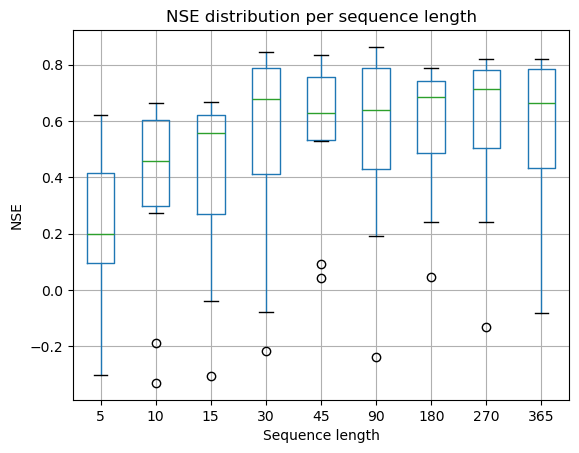

In [10]:
df_nse.boxplot()
plt.ylabel("NSE")
plt.xlabel("Sequence length")
plt.title("NSE distribution per sequence length")
plt.show()

# Ensemble

In [17]:
def nse(obs: xr.DataArray, sim: xr.DataArray) -> float:
    obs, sim = xr.align(obs, sim)

    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs.where(mask, drop=True)
    sim = sim.where(mask, drop=True)

    denominator = ((obs - obs.mean())**2).sum()
    numerator = ((sim - obs)**2).sum()

    return float(1 - numerator / denominator)


def mse(obs: xr.DataArray, sim: xr.DataArray) -> float:
    """Calculate mean squared error."""
    obs, sim = xr.align(obs, sim)

    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs.where(mask, drop=True)
    sim = sim.where(mask, drop=True)

    return float(((sim - obs)**2).mean())


def rmse(obs: xr.DataArray, sim: xr.DataArray) -> float:
    """Calculate root mean squared error."""
    return np.sqrt(mse(obs, sim))


def beta_kge(obs: xr.DataArray, sim: xr.DataArray) -> float:
    """Calculate the beta KGE term (ratio of means)."""
    obs, sim = xr.align(obs, sim)

    mask = np.isfinite(obs) & np.isfinite(sim)
    obs = obs.where(mask, drop=True)
    sim = sim.where(mask, drop=True)

    return float(sim.mean() / obs.mean())

In [21]:
precip_name = "_".join(precip_combo)
print(f"Processing: new_wy_{precip_name}")

runs_list = list(runs_dir.glob(f"new_wy_precip_{precip_name}_seed*"))

# if not runs_list:
#     print(f"  No runs found, skipping...")
#     continue

all_seeds_dfs = []

for run in runs_list:
    seed = run.name.split("_seed_")[1].split("_")[0]
    pickle_path = run / "validation" / "model_epoch030" / "validation_results.p"
    
    if not pickle_path.exists():
        continue
        
    with open(pickle_path, "rb") as f:
        data = pickle.load(f)
    
    basin_dfs = []
    
    for basin in data.keys():
        ds = data[basin]['1D']['xr']
        df = ds.to_dataframe().reset_index()
        df = df[df["time_step"] == 0]
        df["basin"] = basin
        df = df.rename(columns={"QObs_mm_d_sim": f"Q_sim_seed_{seed}"})
        df = df[["date", "basin", "QObs_mm_d_obs", f"Q_sim_seed_{seed}"]]
        basin_dfs.append(df)
    
    seed_df = pd.concat(basin_dfs, ignore_index=True)
    all_seeds_dfs.append(seed_df)

# if not all_seeds_dfs:
#     print(f"  No valid data, skipping...")
#     continue

# Start with first seed
results_df = all_seeds_dfs[0]

# Merge remaining seeds
for df in all_seeds_dfs[1:]:
    sim_col = [col for col in df.columns if "Q_sim_seed" in col][0]
    results_df = results_df.merge(
        df[["date", "basin", sim_col]],
        on=["date", "basin"],
        how="left"
    )

# Calculate mean
sim_cols = [col for col in results_df.columns if "Q_sim_seed" in col]
results_df["Q_sim_mean"] = results_df[sim_cols].mean(axis=1)

results_df.to_csv(ensemble_timeseries_dir / f"new_wy_{precip_name}_timeseries.csv", index=False)

# Compute metrics for each basin
metrics_data = []

for basin, df_basin in results_df.groupby("basin"):
    obs = xr.DataArray(
        df_basin["QObs_mm_d_obs"].values,
        dims=["time"],
        coords={"time": df_basin["date"].values}
    )
    sim = xr.DataArray(
        df_basin["Q_sim_mean"].values,
        dims=["time"],
        coords={"time": df_basin["date"].values}
    )
    
    metrics_data.append({
        "basin": basin,
        "NSE": nse(obs, sim),
        "RMSE": rmse(obs, sim),
        "MSE": mse(obs, sim),
        "Beta-KGE": beta_kge(obs, sim)
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(ensemble_metrics_dir / f"new_wy_{precip_name}.csv", index=False)
print(f"  Saved: new_wy_{precip_name}.csv")

Processing: new_wy_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day
  Saved: new_wy_prcp_mm_day_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day.csv
